
# **New Section # 19**
**Hyper-Parameters Tuning using GridSearch and RandomizedSearch**


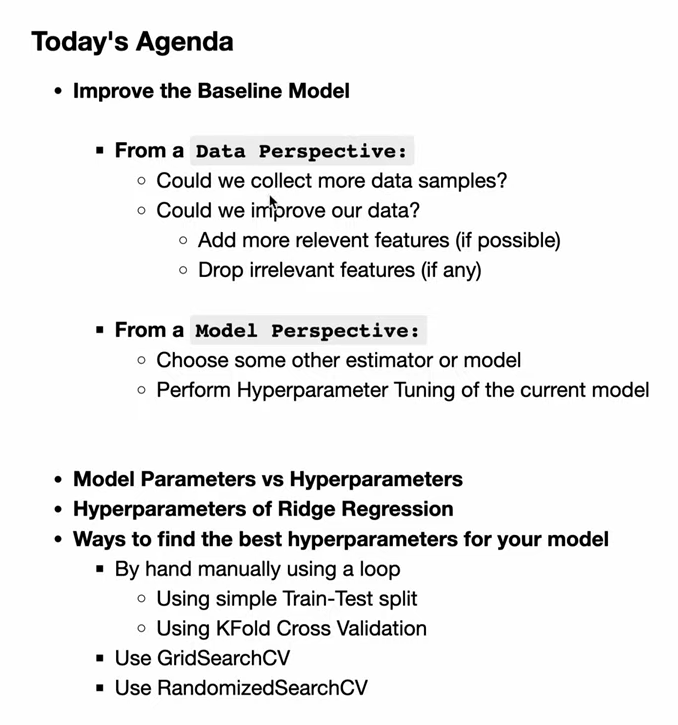


In [2]:
from sklearn.linear_model import Ridge
r = Ridge()
r.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

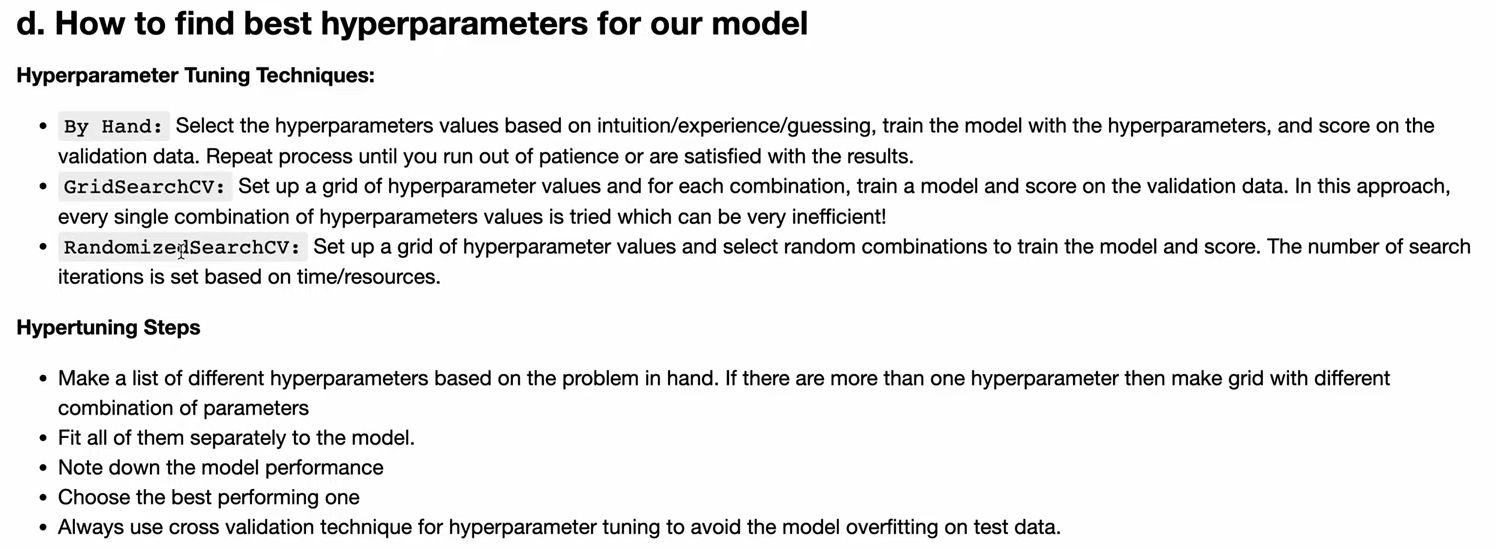


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('sales', axis=1)
y= df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
r = Ridge()
r.fit(X_train, y_train)
r2 = r.score(X_test,y_test)
print("R2 Score: ", r2)

R2 Score:  0.8853545752632082


Hyper Tunning


In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
r = Ridge(alpha=1000.0, solver='auto')
r.fit(X_train, y_train)
r2 = r.score(X_test,y_test)
print("R2 Score: ", r2)

R2 Score:  0.22314589133136864


Least Square


In [10]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
r = Ridge(alpha=100.0, solver='lsqr')
r.fit(X_train, y_train)
r2 = r.score(X_test,y_test)
print("R2 Score: ", r2)

R2 Score:  0.7280835883123569


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

X = df.drop('sales', axis=1)
y= df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

r = Ridge()
r.fit(X_train, y_train)
r2 = r.score(X_test,y_test)
print("R2 Score: ", r2)

R2 Score:  0.7961441823424557


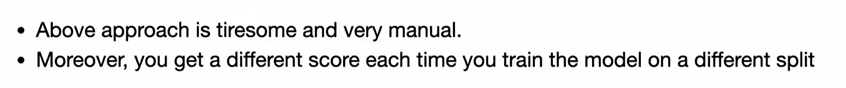

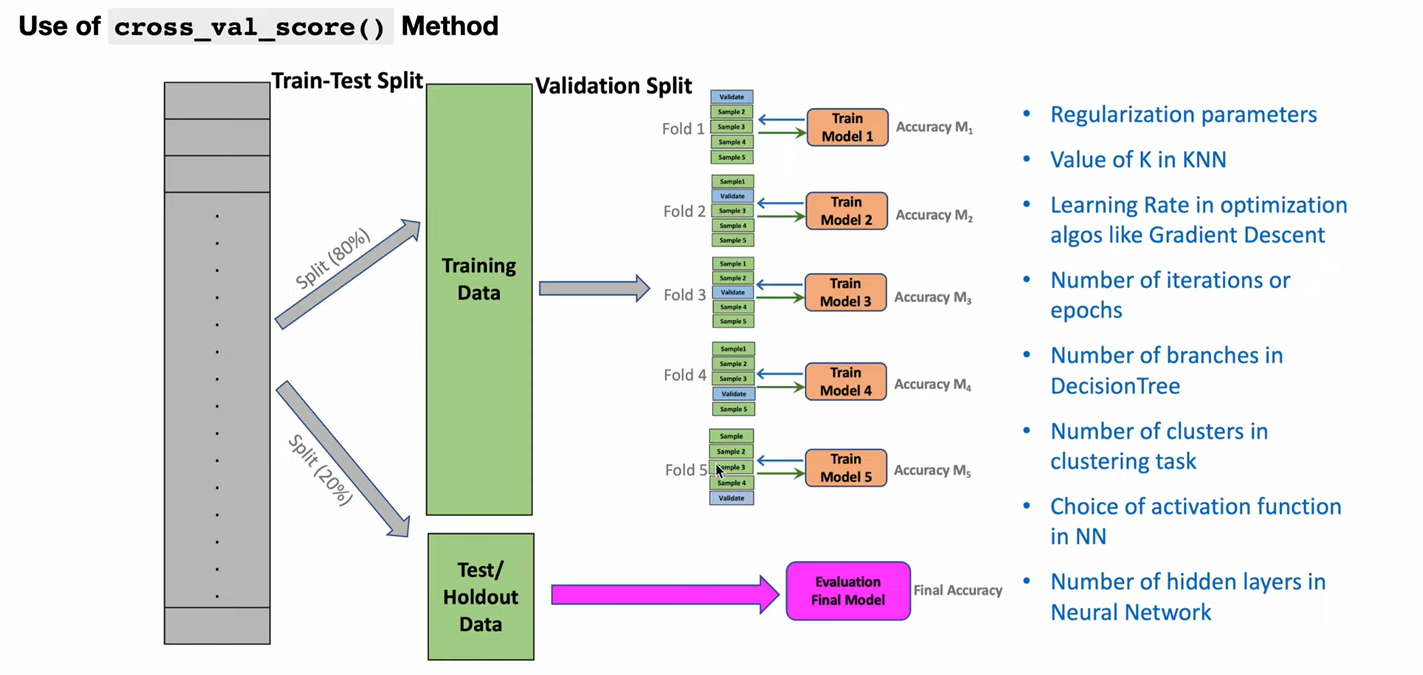


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

X = df.drop('sales', axis=1)
y= df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

cv_score = cross_val_score(
    estimator = Ridge(alpha=100, solver='lsqr'),
    X = X_train,
    y = y_train,
    scoring='r2',
    cv=5
)

print("R2 Scores: ", cv_score)
print("R2: ", np.mean(cv_score))


R2 Scores:  [0.7307449  0.73983559 0.62219356 0.76112206 0.73802486]
R2:  0.7183841938683929


Hpyer and CV using Loop


In [13]:
X = df.drop('sales', axis=1)
y= df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

alphas = [1000, 100, 10, 5, 1, 0.8, 0.5, 0.2]
solver_list = ['lsqr','svd']

for alph in alphas:
  for solve in solver_list:
    cv_score = cross_val_score(
        Ridge(alpha=alph, solver=solve),
        X_train,
        y_train,
        scoring='r2',
        cv=5
        )
    print(alph, solve, ":",np.mean(cv_score))

1000 lsqr : 0.16035793577270044
1000 svd : 0.16035793577270038
100 lsqr : 0.7306426020550406
100 svd : 0.7306426020550406
10 lsqr : 0.8755580223356336
10 svd : 0.8755580223356334
5 lsqr : 0.8763034805213653
5 svd : 0.8763034805213653
1 lsqr : 0.8751249912481978
1 svd : 0.875124991248198
0.8 lsqr : 0.8750182791538637
0.8 svd : 0.8750182791538637
0.5 lsqr : 0.8748490490942382
0.5 svd : 0.874849049094238
0.2 lsqr : 0.8746686819618924
0.2 svd : 0.8746686819618923


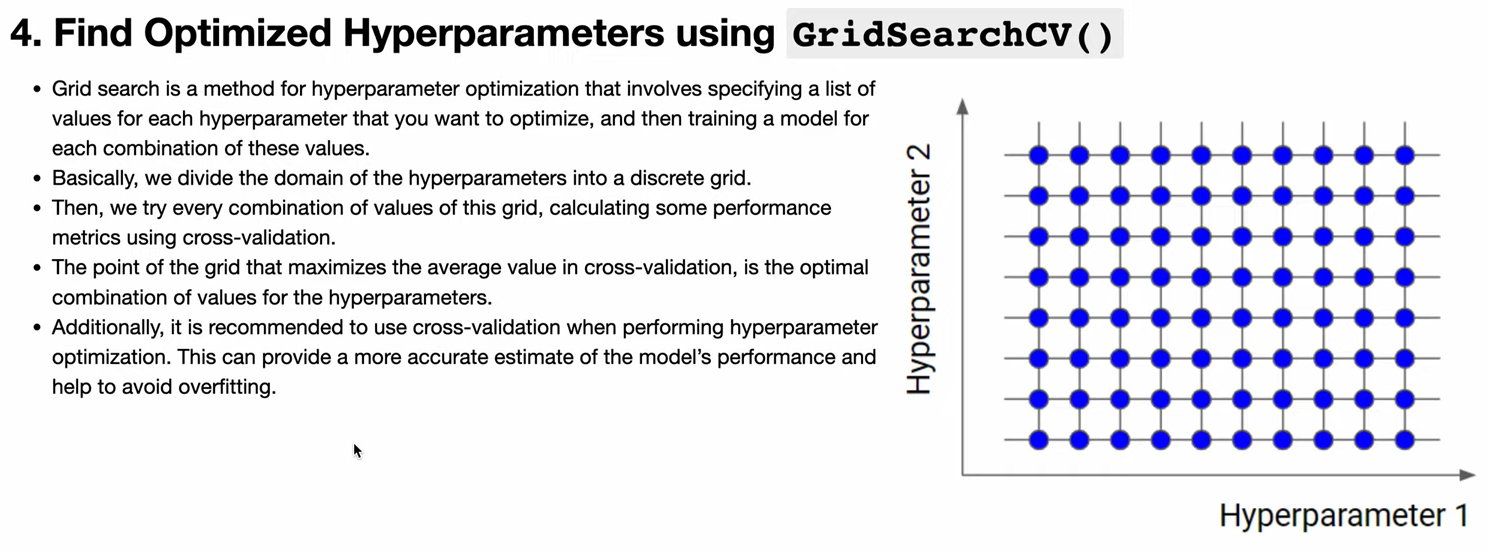


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

X = df.drop('sales', axis=1)
y= df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

params ={
    "alpha" : [1000, 100, 10, 5, 1, 0.8, 0.5, 0.2],
    "solver" : ['lsqr','svd']
}

gs = GridSearchCV(
    estimator=Ridge(),
    param_grid=params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

gs.fit(X_train,y_train)

print("Best Scores: ", gs.best_score_)
print("Best Scores: ", gs.best_params_)

Best Scores:  0.8792844021195986
Best Scores:  {'alpha': 1, 'solver': 'lsqr'}


In [15]:
print(dir(gs))

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_refit_for_multimetric', '_check_scorers_accept_sample_weight', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_format_results', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_params_html', '_get_routed_params_for_fit', '_get_scorers', '_html_repr', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_run_search', '_s

In [16]:
gs.cv_results_


{'mean_fit_time': array([0.00576043, 0.00489616, 0.0060873 , 0.00347095, 0.00443716,
        0.00415387, 0.00479994, 0.00343466, 0.00405378, 0.00388021,
        0.00407391, 0.00305452, 0.00309367, 0.00308256, 0.00475955,
        0.0042768 ]),
 'std_fit_time': array([0.00181495, 0.00187165, 0.00279493, 0.00036978, 0.00084039,
        0.0002919 , 0.00085431, 0.00033637, 0.00035249, 0.00111508,
        0.00085822, 0.0001632 , 0.00016233, 0.00044429, 0.00273066,
        0.0009171 ]),
 'mean_score_time': array([0.00287828, 0.00286899, 0.00239644, 0.00184298, 0.0023725 ,
        0.00199342, 0.00244045, 0.00291758, 0.00261927, 0.0034339 ,
        0.00221806, 0.00175509, 0.00172052, 0.0016737 , 0.00189314,
        0.00223088]),
 'std_score_time': array([4.61758640e-04, 1.94689302e-03, 3.35038648e-04, 7.11553848e-05,
        3.22896294e-04, 1.03024748e-04, 5.02821607e-04, 1.81558758e-03,
        1.28417775e-03, 2.21803729e-03, 4.12770042e-04, 1.38188248e-04,
        1.58957127e-04, 4.61914693e-

In [17]:
df1 = pd.DataFrame(gs.cv_results_)
df1

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005760,0.001815,0.002878,0.000462,1000.0,lsqr,"{'alpha': 1000, 'solver': 'lsqr'}",0.210255,0.226547,0.201695,0.147183,0.176969,0.192530,0.027762,16
1,0.004896,0.001872,0.002869,0.001947,1000.0,svd,"{'alpha': 1000, 'solver': 'svd'}",0.210255,0.226547,0.201695,0.147183,0.176969,0.192530,0.027762,15
2,0.006087,0.002795,0.002396,0.000335,100.0,lsqr,"{'alpha': 100, 'solver': 'lsqr'}",0.756903,0.789382,0.711202,0.640826,0.687747,0.717212,0.052006,13
3,0.003471,0.000370,0.001843,0.000071,100.0,svd,"{'alpha': 100, 'solver': 'svd'}",0.756903,0.789382,0.711202,0.640826,0.687747,0.717212,0.052006,13
4,0.004437,0.000840,0.002373,0.000323,10.0,lsqr,"{'alpha': 10, 'solver': 'lsqr'}",0.898813,0.924926,0.854721,0.821872,0.876925,0.875451,0.035486,11
5,0.004154,0.000292,0.001993,0.000103,10.0,svd,"{'alpha': 10, 'solver': 'svd'}",0.898813,0.924926,0.854721,0.821872,0.876925,0.875451,0.035486,11
6,0.004800,0.000854,0.002440,0.000503,5.0,lsqr,"{'alpha': 5, 'solver': 'lsqr'}",0.898750,0.925640,0.855749,0.827525,0.884900,0.878513,0.034027,10
7,0.003435,0.000336,0.002918,0.001816,5.0,svd,"{'alpha': 5, 'solver': 'svd'}",0.898750,0.925640,0.855749,0.827525,0.884900,0.878513,0.034027,9
8,0.004054,0.000352,0.002619,0.001284,1.0,lsqr,"{'alpha': 1, 'solver': 'lsqr'}",0.896603,0.924645,0.854564,0.830372,0.890239,0.879284,0.033109,1
9,0.003880,0.001115,0.003434,0.002218,1.0,svd,"{'alpha': 1, 'solver': 'svd'}",0.896603,0.924645,0.854564,0.830372,0.890239,0.879284,0.033109,1


In [18]:
df1.loc[:,['param_alpha', 'param_solver', 'mean_test_score']]


,param_alpha,param_solver,mean_test_score
0,1000.0,lsqr,0.192530
1,1000.0,svd,0.192530
2,100.0,lsqr,0.717212
3,100.0,svd,0.717212
4,10.0,lsqr,0.875451
5,10.0,svd,0.875451
6,5.0,lsqr,0.878513
7,5.0,svd,0.878513
8,1.0,lsqr,0.879284
9,1.0,svd,0.879284


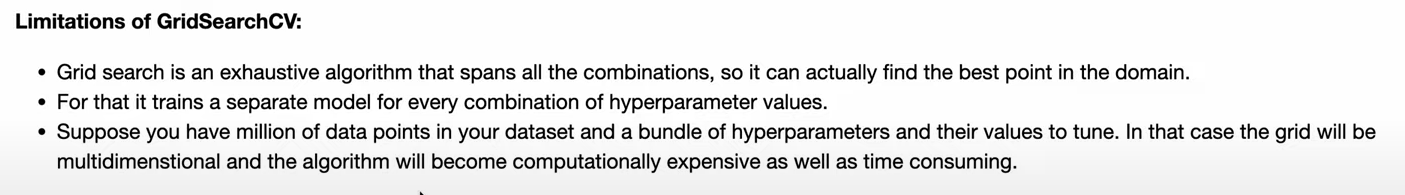

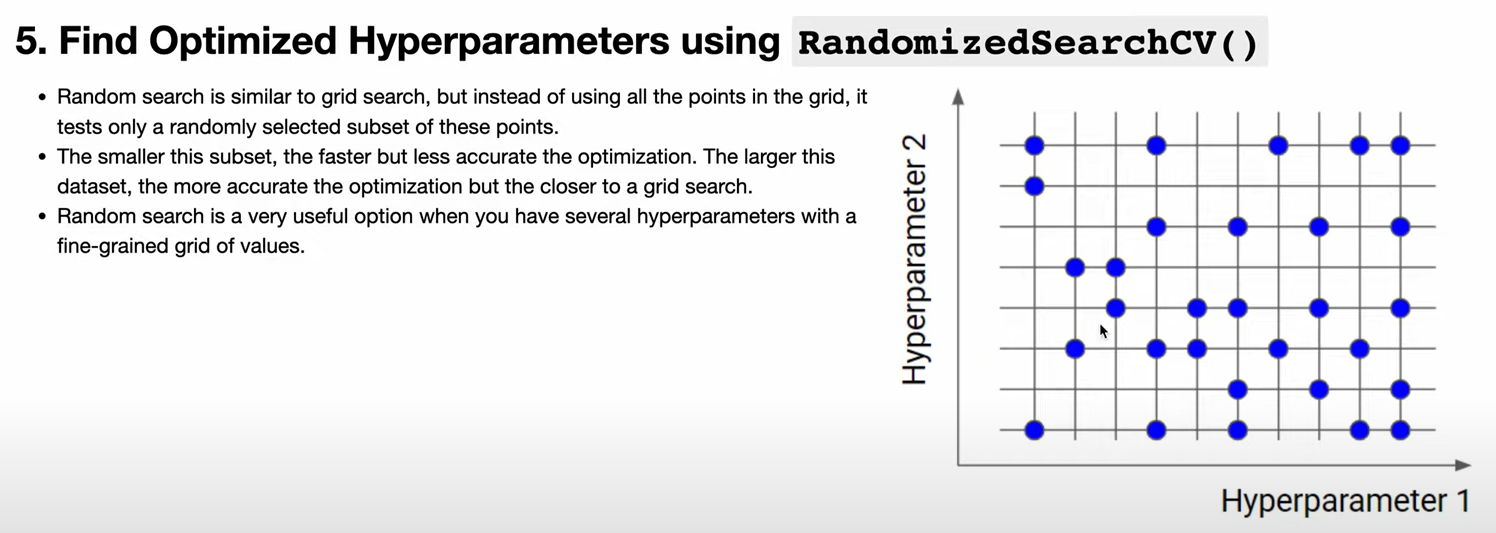


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

X = df.drop('sales', axis=1)
y= df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

params ={
    "alpha" : [1000, 100, 10, 5, 1, 0.8, 0.5, 0.2],
    "solver" : ['lsqr','svd']
}

gs = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=params,
    n_iter= 6,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

gs.fit(X_train,y_train)

print("Best Scores: ", gs.best_score_)
print("Best Scores: ", gs.best_params_)

Best Scores:  0.8698475682142263
Best Scores:  {'solver': 'lsqr', 'alpha': 0.2}
